### **GPU Hardware Verification (`!nvidia-smi`)**

This command launches the **NVIDIA System Management Interface**, a command-line utility used to monitor and manage NVIDIA GPU devices.



* **Confirms GPU Availability:** Verifies that a GPU (such as the Tesla T4) is correctly attached to the environment and that the necessary drivers are loaded.
* **VRAM Monitoring:** Displays real-time video memory usage. This is essential for adjusting batch sizes and preventing "Out of Memory" (OOM) errors during training.
* **Utilization Tracking:** Shows the "GPU-Util" percentage, indicating how much of the GPU's computing power is currently being leveraged.
* **Process Management:** Identifies active programs using the hardware, helping you ensure that background tasks are not competing for resources.

In [18]:
!nvidia-smi

Sat Apr 11 06:37:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             29W /   70W |    4241MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## GPU and Environment Initialization

**Mixed Precision**  
Configures the session to use `float16` for computations, which optimizes the Tensor Cores of the T4 GPU for faster throughput.

**Memory Growth**  
Prevents TensorFlow from allocating all available VRAM at startup, allowing for better resource management on shared environments.

**Determinism**  
Sets global seeds for Python, NumPy, and TensorFlow to ensure reproducible results during model comparison.

**Execution Tuning**  
Defines `STEPS_PER_EXECUTION` to reduce communication overhead between the CPU and GPU during training loops.

In [26]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split

# 1. Enable Mixed Precision for T4 GPU
# This significantly speeds up training on T4 while using less memory
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# 2. GPU Detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Detected: {gpus[0]}")
    except RuntimeError as e:
        print(e)
else:
    print("❌ No GPU found! Check Runtime > Change runtime type.")

# 3. Seeds & Constants
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (300, 300)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
STEPS_PER_EXECUTION = 64

Physical devices cannot be modified after being initialized


## Dataset Acquisition

**Authentication**  
Securely configures the Kaggle API credentials by moving the uploaded `kaggle.json` to the hidden root directory (`~/.kaggle/`) and setting the required read/write permissions.

**Automation**  
Programmatically downloads the **"Human Action Recognition"** dataset directly into the Colab environment using the Kaggle CLI.

**Extraction**  
Decompresses the downloaded ZIP archive to provide local access to the training images and the metadata CSV file.

In [ ]:
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    files.upload() # Upload kaggle.json here
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# meetnagadia/human-action-recognition-har-dataset
!kaggle datasets download -d meetnagadia/human-action-recognition-har-dataset
!unzip -q human-action-recognition-har-dataset.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/meetnagadia/human-action-recognition-har-dataset
License(s): ODbL-1.0
human-action-recognition-har-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Human Action Recognition/Testing_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Human Action Recognition/Training_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Human Action Recognition/test/Image_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Human Action Recognition/test/Image_10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n A
replace Human Action Recognition/test/Image_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Data Pipeline and Augmentation Strategy

**Label Mapping**  
Utilizes `StringLookup` to convert categorical text labels into integer indices based on a sorted vocabulary.

**Preprocessing**  
Implements standardized resizing with padding to maintain aspect ratios while casting images to `float16` for mixed-precision compatibility.

**Mixup Regularization**  
Applies a batch-level Mixup technique that blends pairs of images and their corresponding one-hot labels, significantly improving model generalization and reducing overfitting.

**Performance Optimization**  
Configures a `tf.data` pipeline with parallel mapping, batching, and prefetching to ensure the GPU remains saturated during training.

In [ ]:
DATA_DIR = "Human Action Recognition"
df = pd.read_csv(os.path.join(DATA_DIR, "Training_set.csv"))
df.columns = [c.strip().lower() for c in df.columns]
df["filepath"] = df["filename"].map(lambda x: os.path.join(DATA_DIR, "train", x))

CLASS_NAMES = sorted(df["label"].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)

train_df, val_df = train_test_split(df, train_size=0.8, stratify=df["label"], random_state=SEED)

LABEL_LOOKUP = keras.layers.StringLookup(vocabulary=CLASS_NAMES, mask_token=None, num_oov_indices=0, dtype=tf.int32)



AUGMENTATION = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_FAST") 
    image = tf.image.resize_with_pad(image, IMAGE_SIZE[0], IMAGE_SIZE[1])
    # IMPORTANT: Mixed precision uses float16
    return tf.cast(image, tf.float16), LABEL_LOOKUP(label)


def mixup_batch(images, labels):
    ALPHA = 0.2
    batch_size = tf.shape(images)[0]

    # Generate lambda from Beta distribution
    lam = tf.random.gamma([batch_size], ALPHA)
    lam = lam / (lam + tf.random.gamma([batch_size], ALPHA))

    # --- FIX: Explicitly cast lambda to match image/label dtypes ---
    lam_x = tf.cast(tf.reshape(lam, [batch_size, 1, 1, 1]), images.dtype)
    lam_y = tf.cast(tf.reshape(lam, [batch_size, 1]), labels.dtype)

    idx = tf.random.shuffle(tf.range(batch_size))

    mixed_images = images * lam_x + tf.gather(images, idx) * (tf.cast(1.0, images.dtype) - lam_x)
    mixed_labels = labels * lam_y + tf.gather(labels, idx) * (tf.cast(1.0, labels.dtype) - lam_y)

    return mixed_images, mixed_labels

def make_dataset(frame, training=True):
    ds = tf.data.Dataset.from_tensor_slices((frame["filepath"].values, frame["label"].values))
    if training: ds = ds.shuffle(8192)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(mixup_batch, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

## Comparative Model Architecture and Two-Stage Training Pipeline

**Modular Architecture**  
Implements a flexible factory function that dynamically swaps between EfficientNetB3, ResNet50, and MobileNetV2 backbones while applying model-specific preprocessing.

**Transfer Learning Strategy**  
Initializes training with a **"Warmup"** stage by freezing the pre-trained backbone, allowing the randomly initialized classification head to converge without distorting the learned ImageNet features.

**Selective Fine-Tuning**  
Transitions to a secondary stage where the top 100 layers of the backbone are unfrozen. This allows the model to adapt high-level features to specific gesture nuances while maintaining lower-level edge and texture detectors.

**Batch Normalization Stability**  
Keeps BatchNormalization layers in inference mode (frozen) even during fine-tuning. This is a critical best practice to prevent the moving mean and variance from destabilizing on a new, smaller dataset.

**History Aggregation**  
Programmatically merges metric logs from both training stages, enabling a continuous and unified visualization of the learning curve across the entire 15-epoch schedule.

In [ ]:
def build_comparison_model(model_type):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = AUGMENTATION(inputs)

    #Transfer Learning
    if model_type == "EfficientNetB3":
        # Internal scaling
        backbone = keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    elif model_type == "ResNet50":
        # Needs ResNet preprocessing
        prep = keras.applications.resnet50.preprocess_input(x)
        backbone = keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=prep)
    elif model_type == "MobileNetV2":
        # Needs MobileNet preprocessing
        prep = keras.applications.mobilenet_v2.preprocess_input(x)
        backbone = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_tensor=prep)

    backbone.trainable = False
    x = keras.layers.GlobalAveragePooling2D()(backbone.output)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    
    # Output must be float32 for softmax stability
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    return keras.Model(inputs, outputs, name=model_type), backbone

model_names = ["EfficientNetB3", "ResNet50", "MobileNetV2"]
trained_models = {}
all_histories = {}

for name in model_names:
    print(f"\n🚀 TRAINING: {name}")
    keras.backend.clear_session()
    model, backbone = build_comparison_model(name)

    # --- STAGE 1: Warmup (Frozen Backbone) ---
    model.compile(optimizer=keras.optimizers.AdamW(5e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    # Capture the history object
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=2)

    # --- STAGE 2: Fine-Tuning (Unfreeze Last 100 Layers) ---
    print(f"Unfreezing {name} for fine-tuning...")
    backbone.trainable = True
    for layer in backbone.layers[:-100]: layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, keras.layers.BatchNormalization): layer.trainable = False

    model.compile(optimizer=keras.optimizers.AdamW(5e-5), loss="categorical_crossentropy", metrics=["accuracy"])
    # Capture the second stage history
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=13, initial_epoch=2,
                  callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])

    trained_models[name] = model

    # --- MERGE HISTORIES ---
    # We combine both stages so the graph shows a continuous line from epoch 1 to 15
    combined = {}
    for key in h1.history.keys():
        combined[key] = h1.history[key] + h2.history[key]

    all_histories[name] = combined
    model.save(f"{name}_final.keras")


🚀 TRAINING: EfficientNetB3
Epoch 1/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 144s 692ms/step - accuracy: 0.3420 - loss: 2.3816 - val_accuracy: 0.6246 - val_loss: 1.3953
Epoch 2/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 102s 646ms/step - accuracy: 0.4771 - loss: 1.8750 - val_accuracy: 0.6782 - val_loss: 1.0768
Unfreezing EfficientNetB3 for fine-tuning...
Epoch 3/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 156s 819ms/step - accuracy: 0.5770 - loss: 1.6009 - val_accuracy: 0.7254 - val_loss: 0.9036
Epoch 4/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 124s 781ms/step - accuracy: 0.6365 - loss: 1.4349 - val_accuracy: 0.7607 - val_loss: 0.8187
Epoch 5/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 123s 780ms/step - accuracy: 0.6645 - loss: 1.3207 - val_accuracy: 0.7671 - val_loss: 0.7790
Epoch 6/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 143s 786ms/step - accuracy: 0.6937 - loss: 1.2367 - val_accuracy: 0.7869 - val_loss: 0.7287
Epoch 7/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 123s 778ms/step - accuracy: 0.7065 - loss: 1.1719 - val_accuracy: 0.7909 - val_loss: 0.7268
Epoch

/tmp/ipykernel_492/3359216404.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_tensor=prep)


Epoch 1/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 357ms/step - accuracy: 0.2926 - loss: 2.5547 - val_accuracy: 0.5250 - val_loss: 1.5941
Epoch 2/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 76s 327ms/step - accuracy: 0.4316 - loss: 2.0206 - val_accuracy: 0.5790 - val_loss: 1.3308
Unfreezing MobileNetV2 for fine-tuning...
Epoch 3/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 72s 373ms/step - accuracy: 0.4913 - loss: 1.8289 - val_accuracy: 0.5508 - val_loss: 1.4625
Epoch 4/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 56s 354ms/step - accuracy: 0.5606 - loss: 1.6275 - val_accuracy: 0.6274 - val_loss: 1.2200
Epoch 5/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 61s 380ms/step - accuracy: 0.5943 - loss: 1.5018 - val_accuracy: 0.6599 - val_loss: 1.1027
Epoch 6/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 359ms/step - accuracy: 0.6148 - loss: 1.4268 - val_accuracy: 0.6869 - val_loss: 0.9957
Epoch 7/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 364ms/step - accuracy: 0.6375 - loss: 1.3731 - val_accuracy: 0.6984 - val_loss: 0.9929
Epoch 8/13
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s

## Training Visualization and Comparative Analysis

**Learning Curve Visualization**  
Generates dual-pane charts to track the convergence of EfficientNetB3, ResNet50, and MobileNetV2, allowing for a direct comparison of their generalization capabilities.

**Stage Transition Marker**  
Includes a vertical indicator at the transition point (Epoch 2.5) to highlight the impact of switching from frozen-backbone **"Warmup"** to unfrozen **"Fine-tuning."**

**Overfitting Diagnosis**  
Overlays training vs. validation metrics; a widening gap between solid (train) and dashed (validation) lines serves as a visual diagnostic for potential variance issues or the need for stronger regularization.

**Numerical Stability Check**  
The loss curves provide insight into the effectiveness of the AdamW optimizer and Mixed Precision settings, specifically monitoring for spikes or plateaus that might suggest an inappropriate learning rate.

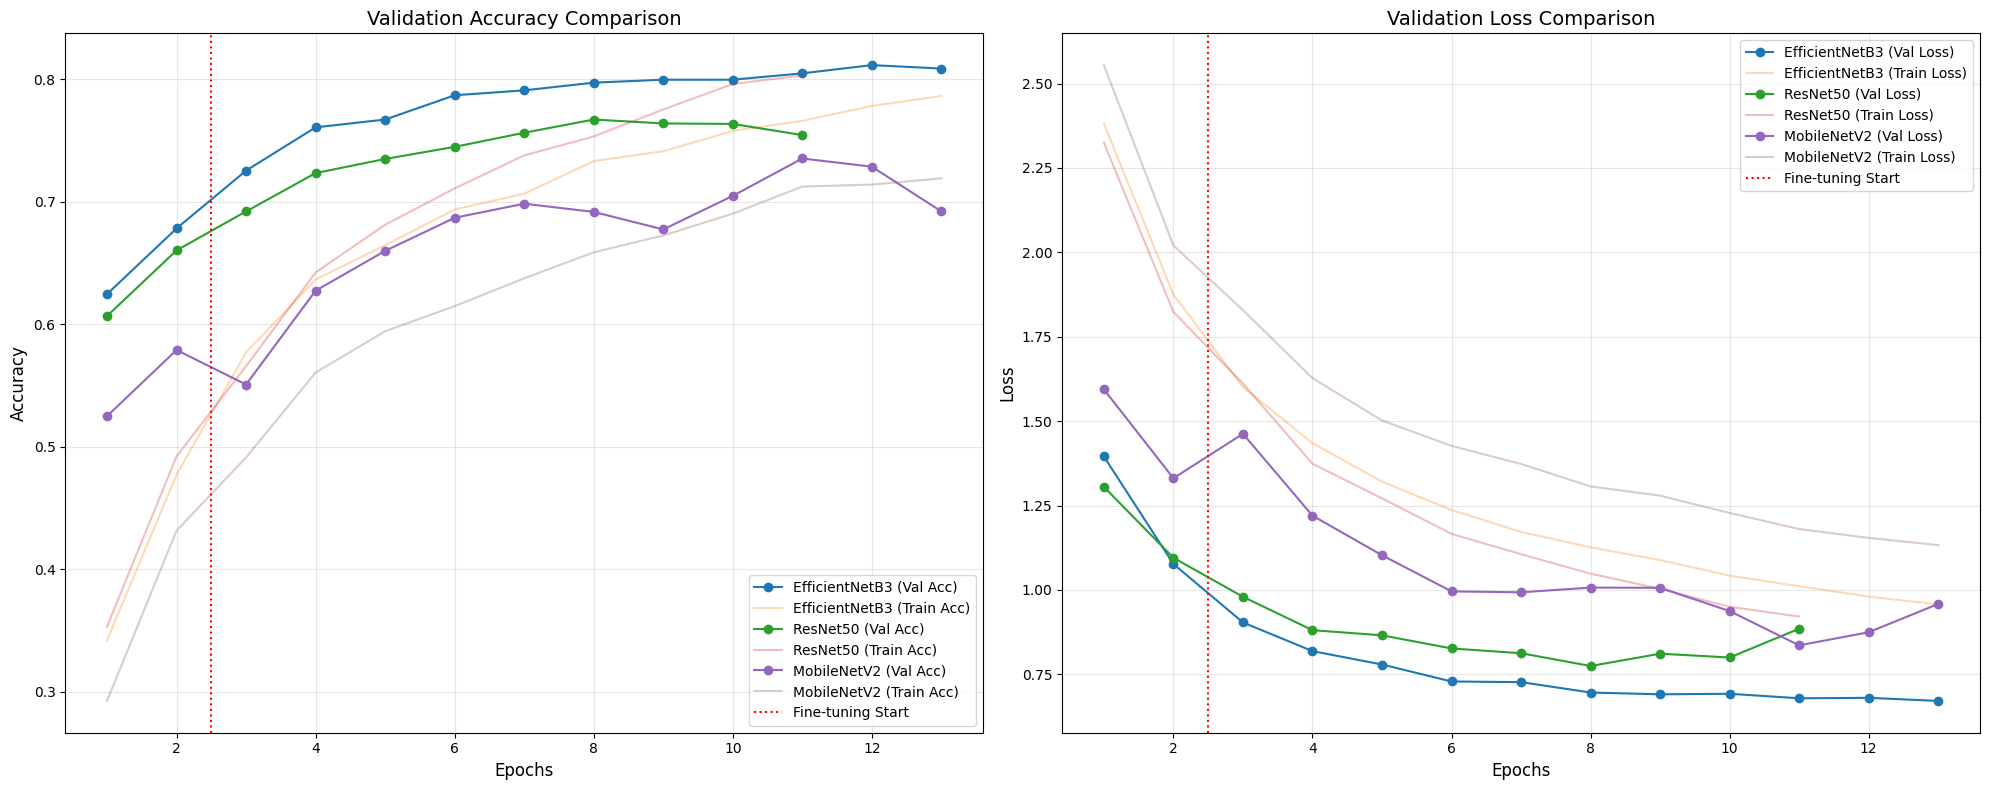

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(histories):
    if not histories:
        print("No data found in histories dictionary. Ensure the training loop is capturing h1 and h2.")
        return

    plt.figure(figsize=(20, 8))

    # --- Subplot 1: Accuracy ---
    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        val_acc = history['val_accuracy']
        epochs = range(1, len(val_acc) + 1)
        plt.plot(epochs, val_acc, label=f'{name} (Val Acc)', linestyle='--')
        plt.plot(epochs, history['accuracy'], label=f'{name} (Train Acc)', alpha=0.3)

    plt.title('Validation Accuracy Comparison', fontsize=14)
    plt.xlabel('Total Epochs (Warmup + Fine-tune)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.axvline(x=2.5, color='r', linestyle=':', label='Fine-tuning Start')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # --- Subplot 2: Loss ---
    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        val_loss = history['val_loss']
        epochs = range(1, len(val_loss) + 1)
        plt.plot(epochs, val_loss, label=f'{name} (Val Loss)', linestyle='--')
        plt.plot(epochs, history['loss'], label=f'{name} (Train Loss)', alpha=0.3)

    plt.title('Validation Loss Comparison', fontsize=14)
    plt.xlabel('Total Epochs (Warmup + Fine-tune)', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.axvline(x=2.5, color='r', linestyle=':', label='Fine-tuning Start')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_training_results(all_histories)



## Training Visualization and Comparative Analysis

**Learning Curve Visualization**  
Generates dual-pane charts to track the convergence of EfficientNetB3, ResNet50, and MobileNetV2, allowing for a direct comparison of their generalization capabilities.

**Stage Transition Marker**  
Includes a vertical indicator at the transition point (Epoch 2.5) to highlight the impact of switching from frozen-backbone **"Warmup"** to unfrozen **"Fine-tuning."**

**Overfitting Diagnosis**  
Overlays training vs. validation metrics; a widening gap between solid (train) and dashed (validation) lines serves as a visual diagnostic for potential variance issues or the need for stronger regularization.

**Numerical Stability Check**  
The loss curves provide insight into the effectiveness of the AdamW optimizer and Mixed Precision settings, specifically monitoring for spikes or plateaus that might suggest an inappropriate learning rate.


--- EfficientNetB3 Evaluation ---
                    precision    recall  f1-score   support

           calling       0.80      0.70      0.75       168
          clapping       0.85      0.75      0.79       168
           cycling       0.98      0.98      0.98       168
           dancing       0.84      0.80      0.82       168
          drinking       0.87      0.88      0.88       168
            eating       0.91      0.89      0.90       168
          fighting       0.78      0.90      0.84       168
           hugging       0.79      0.87      0.83       168
          laughing       0.75      0.79      0.77       168
listening_to_music       0.73      0.65      0.69       168
           running       0.87      0.84      0.85       168
           sitting       0.67      0.69      0.68       168
          sleeping       0.86      0.83      0.85       168
           texting       0.67      0.68      0.68       168
      using_laptop       0.76      0.88      0.82       168

   

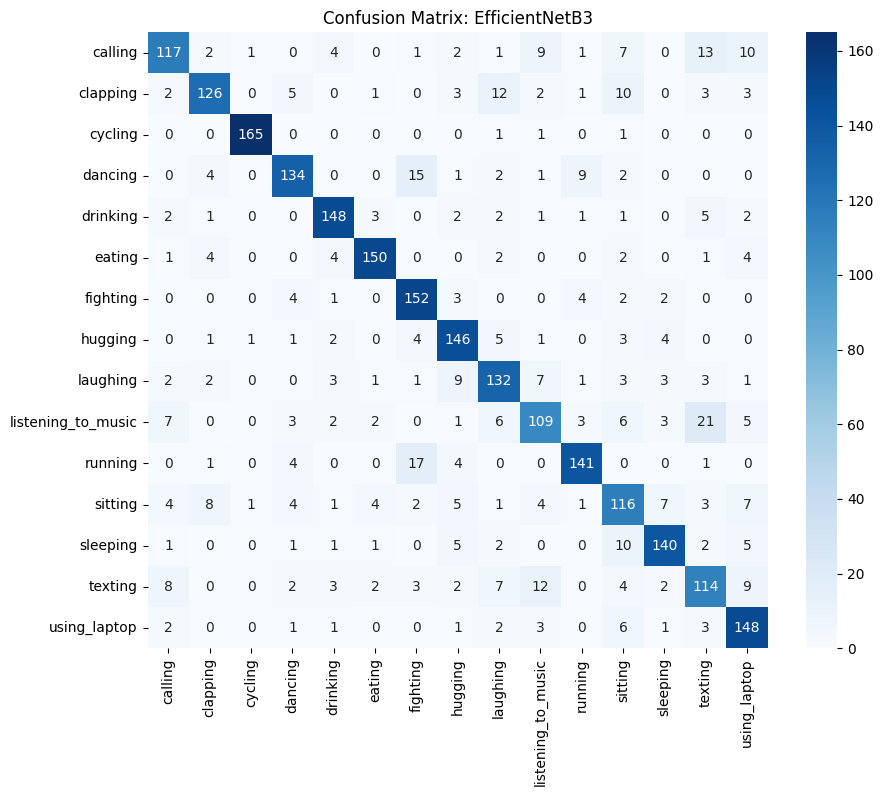


--- ResNet50 Evaluation ---
                    precision    recall  f1-score   support

           calling       0.65      0.74      0.69       168
          clapping       0.91      0.57      0.70       168
           cycling       0.96      0.98      0.97       168
           dancing       0.76      0.75      0.76       168
          drinking       0.85      0.77      0.81       168
            eating       0.93      0.83      0.88       168
          fighting       0.86      0.77      0.81       168
           hugging       0.69      0.90      0.78       168
          laughing       0.77      0.81      0.79       168
listening_to_music       0.62      0.65      0.64       168
           running       0.89      0.75      0.82       168
           sitting       0.57      0.64      0.60       168
          sleeping       0.82      0.84      0.83       168
           texting       0.78      0.62      0.69       168
      using_laptop       0.66      0.89      0.75       168

         

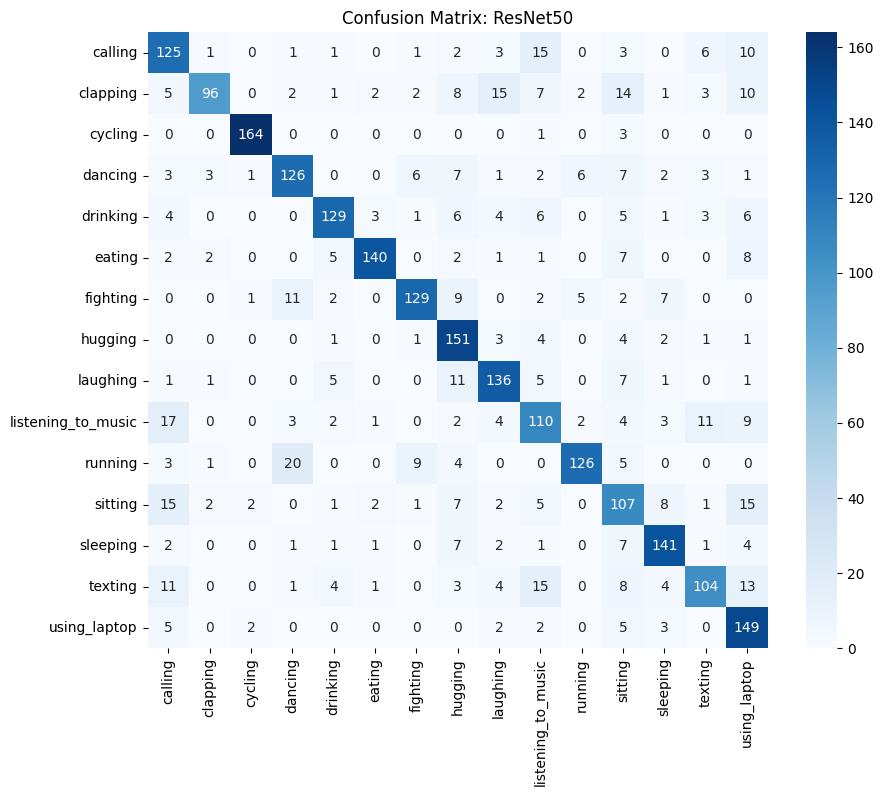


--- MobileNetV2 Evaluation ---
                    precision    recall  f1-score   support

           calling       0.65      0.61      0.63       168
          clapping       0.77      0.70      0.73       168
           cycling       0.92      0.99      0.95       168
           dancing       0.77      0.68      0.73       168
          drinking       0.79      0.79      0.79       168
            eating       0.85      0.89      0.87       168
          fighting       0.86      0.72      0.78       168
           hugging       0.67      0.76      0.71       168
          laughing       0.85      0.62      0.71       168
listening_to_music       0.56      0.60      0.58       168
           running       0.86      0.79      0.83       168
           sitting       0.56      0.60      0.58       168
          sleeping       0.78      0.79      0.78       168
           texting       0.72      0.58      0.64       168
      using_laptop       0.59      0.91      0.71       168

      

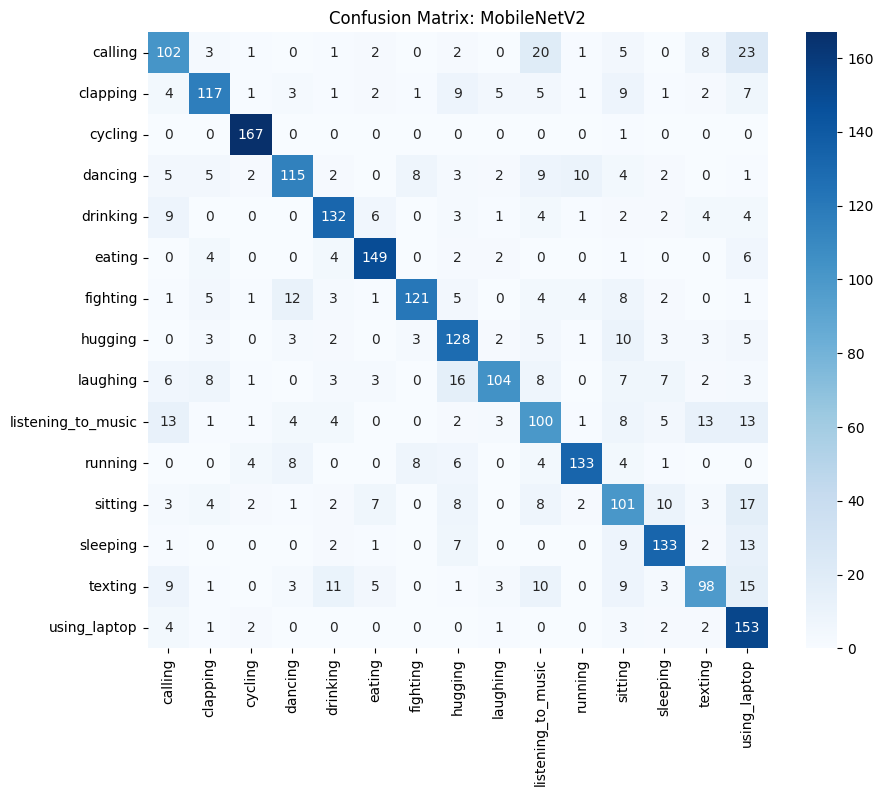

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def run_full_evaluation():
    for name in model_names:
        print(f"\n--- {name} Evaluation ---")
        y_true, y_pred = [], []
        for imgs, lbls in val_ds:
            preds = trained_models[name].predict(imgs, verbose=0)
            y_true.extend(np.argmax(lbls.numpy(), axis=1)) #actual values
            y_pred.extend(np.argmax(preds, axis=1)) #predicted values

        # Classification Report
        print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f"Confusion Matrix: {name}")
        plt.show()

run_full_evaluation()

## Multi-Model Inference and Qualitative Comparison

**Prediction Test**  
Performs side-by-side comparison of how EfficientNetB3, ResNet50, and MobileNetV2 interpret the same unseen image from the validation set.

**Visual Verification**  
Provides a qualitative **"sanity check"** by displaying the input image alongside the top predicted label and the model's confidence score (Softmax output).

**Data Normalization for Display**  
Specifically handles the conversion of `float16` tensors (used for GPU efficiency) back to `float32` and applies min-max scaling to ensure the image renders correctly in Matplotlib.

**Confidence Scoring**  
Visualizes the model's certainty; comparing these scores across models helps identify if a model is **"over-confident"** in wrong predictions or **"hesitant"** (low confidence) on difficult edge cases.

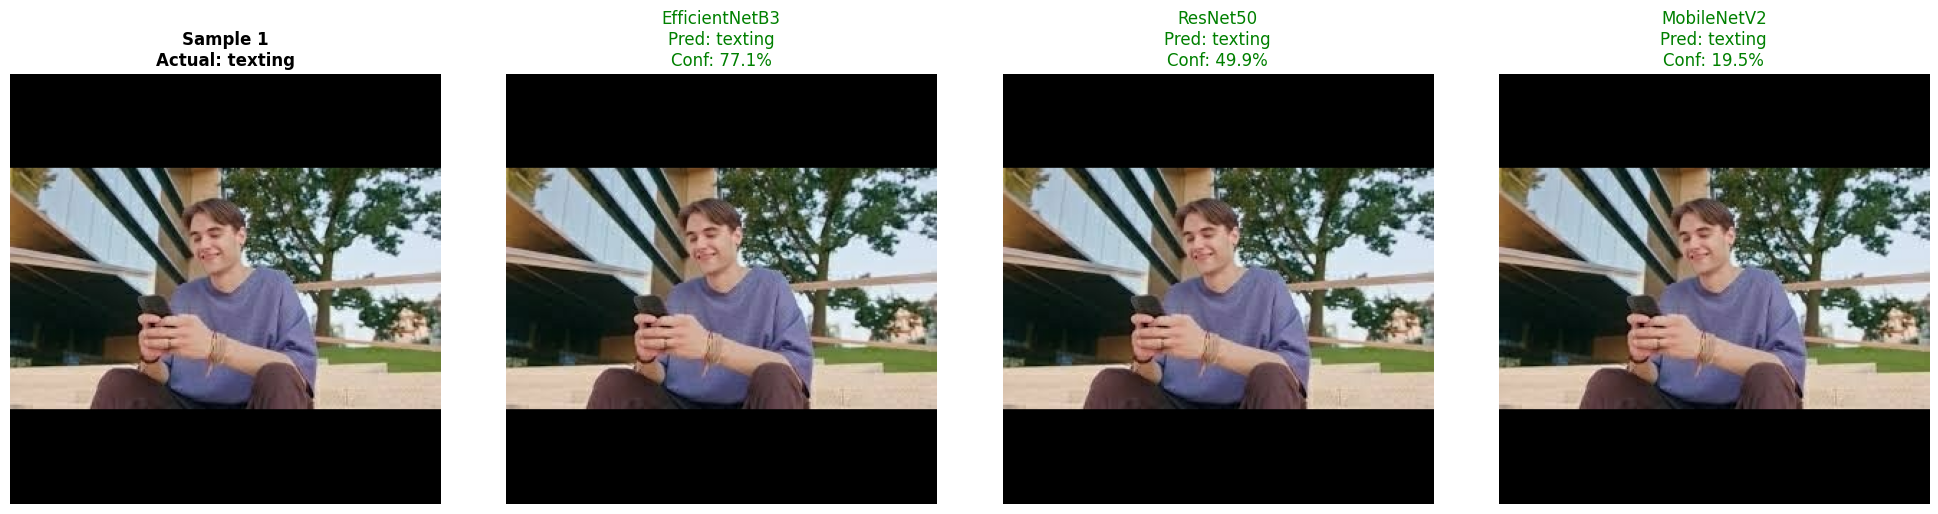

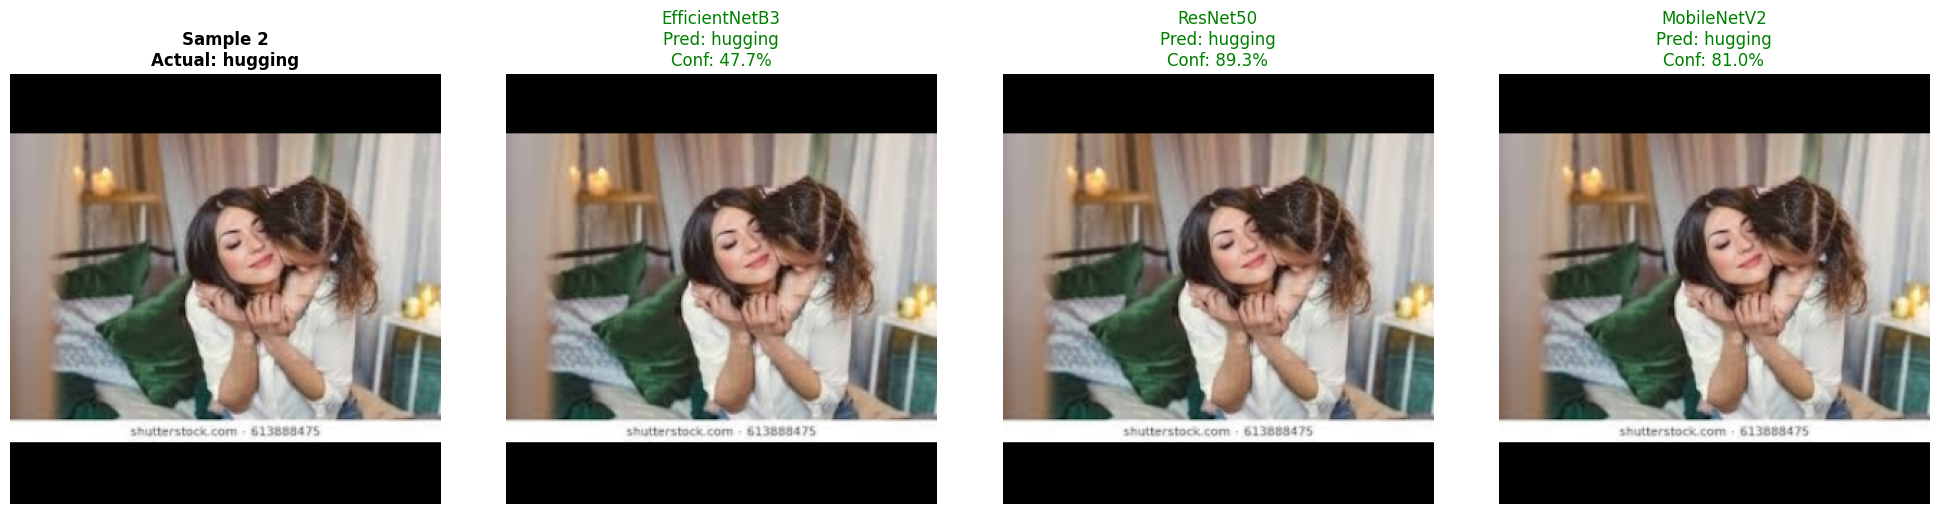

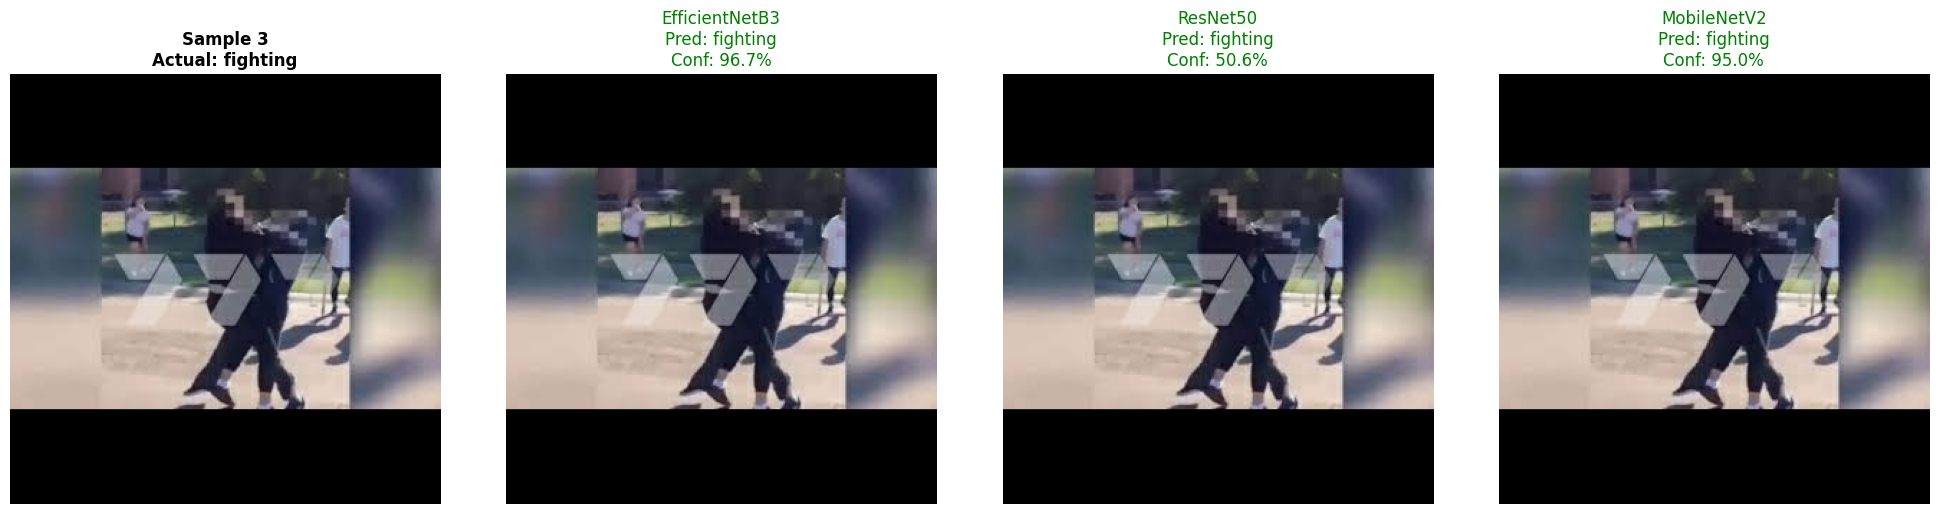

In [ ]:
def compare_inference_multiple(num_samples=3):
    # Take a batch of random samples by shuffling the validation set each time
    # unbatch() + shuffle() ensures we pick different images every run
    sample_iterator = iter(val_ds.unbatch().shuffle(len(val_df)).batch(1).take(num_samples))

    for s in range(num_samples):
        img_batch, label_batch = next(sample_iterator)
        img, true_idx = img_batch[0], np.argmax(label_batch[0])

        plt.figure(figsize=(20, 5))

        # 1. Display Original Image
        plt.subplot(1, 4, 1)
        display_img = tf.cast(img, tf.float32).numpy()
        display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
        plt.imshow(display_img)
        plt.title(f"Sample {s+1}\nActual: {CLASS_NAMES[true_idx]}", fontweight='bold')
        plt.axis("off")

        # 2. Predict with each trained model
        for i, name in enumerate(model_names):
            pred = trained_models[name].predict(img_batch, verbose=0)
            p_idx = np.argmax(pred)  # [0.2,0.1,0.7] 0, 1, 2   [running, sleeping, eating]
            conf = np.max(pred)

            # Green for correct prediction, Red for incorrect
            color = 'green' if p_idx == true_idx else 'red'

            plt.subplot(1, 4, i+2)
            plt.imshow(display_img)
            plt.title(f"{name}\nPred: {CLASS_NAMES[p_idx]}\nConf: {conf:.1%}", color=color)
            plt.axis("off")

        plt.tight_layout()
        plt.show()

compare_inference_multiple(num_samples=3)